# Machine Learning for Everybody
- source: https://www.youtube.com/watch?v=i_LwzRVP7bg&t=4073s
- February 14, 2026

## Notes — Feb 22, 2026

- Watched: Lecture 03 — Feature Engineering
- Key takeaways:
  - Scale numeric features (StandardScaler / MinMax).
  - Handle class imbalance (oversampling / class weights).
- Next actions:
  1. Implement scaling pipeline in `sklearn`
  2. Try RandomOverSampler and compare metrics

Replace this placeholder with your full notes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

- Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by: P.Savicky Institute of Computer Science.

In [ ]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "FM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("data/magic04.data", names=cols)
df.head()

In [ ]:
df["class"] = (df["class"] == "g").astype(int)
df.head()

# What is Machine Learning?

- Machine learning is a subdomain of computer science that focuses on algorithms which help a computer learn from data without explicit programming. 

## AI vs ML vs DS
- **Artificial Intelligence** is an area of computer science, where the goal is to enable computers and machines to perform human-like tasks and simulate human behavior. 
- **Machine Learning** is a subset of AI that tries to solve a specific problem and make predictions using data. 
- **Data Science** is a field that attempts to find patterns and draw insights from data (might use ML!)

All fields overlap, and may use ML!

# Types of Machine Learning
- **Supervised learning** - uses labeled inputs (meaning the input has a corresponding label) to train models and learn outputs.
- **Unsupervised learning** - uses unlabeled data to learn about patterns in data. 
- **Reinforcement learning** - agent learning in interactive environment based on rewards and penalities. 

# Supervised Learning
- In general, you have a bunch of inputs that you feed into a model, and the model outputs something, usually a prediction. 
- We call the inputs a **feature vector**. 

## Features
- **Qualitative** - categorical data (finite number of categories or groups)
- Qualitative data is **Nominal Data** because there is no inherent order.
- For nominal data, we use one-hot encoding (think dummy variables in economics). This is where you assign "1" if data matches a specific category. 
- **Ordinal Data** has an inherent order. For these types of datasets, we can mark them, from 1-5 for example. 
- **Quantitative** numerical valued data (could be discrete or continuous). Discrete could be integers, continuous could be all real numbers. 


# Output (Types of Predictions)

## Supervised Learning Tasks
- **Classification** - predict discrete classes
    - Multi-class classification (more than 2 categories).
        - Positive/negative
        - Cat/dog
        - Spam/not spam
    - Binary classification (2 categories).
        - Cat/dog/lizard/dolphin
        - Orange/apple/pear
        - Plant species
- **Regression** - predict continuous values
    - Price of Ethereum tomorrow.
    - Temperature
    - Price of a house


# The Model
- How do we make the model learn? How can we tell whether or not it's learning?

## Supervised Learning Dataset 
- Diabetes dataset. 
- Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Age, Outcome]
- Each row is a different sample in the data. It's one person's data. 
- Each column is a different feature. 
- The outcome column is the output label. 
- One row less the output label is what we'd call a feature vector. The output label for a row is the target for that feature vector.
- All of the features (less the output labels) is what we'd call the features matrix, $X$. 
- All of the outcomes are our labels/targets vector, $y$. 

- We "train" the model to see how we can make it more accurate. We typically don't feed all of our data into our model because we want to determine how well our model generalizes. We separate our data into a training dataset, a validation dataset, and a testing dataset. Usually the split could be 80%, 10%, 10%. The difference between our prediction and the true values is known as **loss**. Validation set used as a reality check during/after training to ensure model can handle unseen data.

- Test set used as to check how generalizable the final chosen model is. 

## Metrics of Performance
- **Loss** is the difference between your prediction and the actual label. Here is an example of $L1$ loss:
$$ \text{loss} = \text{sum}(|y_{real} - y_{predicted}) $$
The further off you are, the greater your loss is. Another measure of loss is $L2$ loss:
$$ \text{loss} = \text{sum}((y_{real} - y_{predicted})^2) $$
The $L2$ loss function is quadratic, which means as it's more off, the greater the penalty is. There's also something called **Binary Cross-Entropy Loss**, denoted as :
$$ \text{loss} = \frac{1}{\text{sum}(y_{real} * log(y_{predicted}) + (1-y_{real}) * log((1-y_{predicted})) )} $$
The loss decreases as the performance gets better. 

- **Accuracy** 
    - Predictions:
        - Apple
        - Orange
        - Orange
        - Apple
    - Actual:
        - Apple
        - Orange
        - Apple
        - Apple
    In this case, the accuracy is 75\%. 

In [ ]:
for label in cols[:-1]: # exclude the class
    plt.hist(df[df["class"] == 1][label], color='blue', label='gamma', alpha=0.7, density=True)
    plt.hist(df[df["class"] == 0][label], color='red', label='hadron', alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [ ]:
train, valid, test = np.split(
    df.sample(frac=1), 
    [int(0.6*len(df)), 
    int(0.8*len(df))])


In [ ]:
train

In [ ]:
def scale_dataset(dataframe, oversample=False):
    X = dataframe[dataframe.columns[:-1]].values # everything up to the last column
    y = dataframe[dataframe.columns[-1]].values # only the last column

    scaler = StandardScaler()
    X = scaler.fit_transform(X) # take X and fit the standard scaler to X, and then transform all of those values

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y) # Take more of the 'less' class and keep sampling from there to increase the size of our dataset for that lower class so they now match.

    data = np.hstack((X, np.reshape(y, (-1, 1)))) # creates a 2-d numpy array

    return data, X, y

In [ ]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False) # Oversample set to false to make sure our data performs well on a random set of data that isn't necessarily balanced. 
test, X_test, y_test = scale_dataset(test, oversample=False)

# K Nearest Neighbors

Given the graph below, let's define distance and classify some points. 

In [ ]:
sample_data = {
    'number_of_kids': [3, 4, 1, 5, 3, 2, 2, 4, 1, 0, 3, 2, 1, 4, 0],
    'income': [40, 40, 80, 100, 120, 160, 170, 165, 200, 240, 240, 250, 290, 300, 320],
    'shape': ['-', '-', '-', '+', '-', '-', '+', '+', '-', '+', '-', '+', '+', '-', '+']
}

markers = {'-': 'o', '+': 'P'}

sample_df = pd.DataFrame(sample_data)

for shape_value, marker in markers.items():
    subset = sample_df[sample_df['shape'] == shape_value]
    plt.scatter(subset['number_of_kids'], subset['income'], marker=marker, label=f"Shape {shape_value}")
plt.scatter(2, 40, color='green', marker='*', s=200, label='New Point')
plt.plot([2, 1], [40, 80], color='purple', linewidth=2, label='Euclidean Distance')
plt.plot([2, 3], [40, 40], color='purple', linewidth=2, label='Euclidean Distance')
plt.plot([2, 3], [40, 120], color='purple', linewidth=2, label='Euclidean Distance')
plt.text(0.5, 140, "k=3", color='red', fontsize=12)
plt.xlabel('Number of Kids')
plt.ylabel('Income ($/year)')
plt.title('Income vs. Number of Kids')
plt.show()


In this example, the $+$ means the family owns a car, and the normal 'dot' means the family doesn't own a car. 

Each of these points is a sample that has a corresponding label. Thus it is binary classification. Let's say we have a new point, where they make $40,000 a year and have two kids. What do we think that will be? Well, one way to make this prediction is to use the labels of nearby points. Thus, if we do that in this case we'd predict that this family doesn't have a car. 

In 2-d plots like this, we often use something called 'Euclidean Distance', which is the straight-line distance between two points. This formula is:

$$ d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$

The $k$ in k-nearest neighbors tells us how many neighbors we use in order to determine a label. Usually we may use a $k$ of 3 or 5, depending on the size of the dataset. If $k=3$ in this case, the three closest points are three points highlighted in the graph above, which in this case would indicate that our prediction is that this family doesn't own a car. The prediction would just be the majority of the nearby points. 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)

In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
print(classification_report(y_test, y_pred))

In this case,  accuracy is 79\%.

- Accuracy is how many we got right out of the total.
- Precision is saying out of how many of the labels that are true positives, how many did we label as positive. It's how many retrieved items are relevant.
- Recall is how many relevant items are retrieved. It's out of all the ones that we know are truly positive, how many did we actually get right? 

Therefore, our precision for predicting gammas is 87\% and our precision for predicting hadrons is 73\%. Similarly, our recall for gammas is 67\% and our recall for hadrons is 90\%. 

Our f1-score is a combination of our precision and recall. 

# Naive Bayes

## Covid Test Result
|                | Test Positive | Test Negative | Row Total |
|----------------|:-------------:|:-------------:|:---------:|
| Covid Positive |     531       |      6        |   537     |
| Covid Negative |     20        |     9443      |   9463    |
| **Col Total**  |     551       |     9449      |  10000    |


- **What is the probability of having covid given a positive test?**
    - This can be written as $P(covid|+_{test}) = 531/551 \approx 96.4\%$

## Bayes' Rule
$$ P(A|B) = \frac{P(B|A) * P(A)}{P(B)} $$

In this case, $B$ is our condition. 

$P(\text{false positive}) = 0.05$

$P(\text{false negative}) = 0.01$

$P(\text{disease}) = 0.1$

Given this information, what is $P(\text{disease}|\text{+}_{test} )$?

Well, we can rewrite $P(\text{false positive})$ as $P(+|\text{no disease})$, similarly we can rewrite $(P(\text{false negative}))$ as $P(-|\text{disease})$. 

Given this information, we have:
|                | Test Positive  | Test Negative  |
|----------------|:--------------:|:--------------:|
| Disease        |       0.99     |       0.01     |
| No Disease     |       0.05     |       0.95     |


Using this information, and Bayes Rule, we have:
$$  P(disease|test_{positive}) = \frac{P(positive_{\text{disease}}) * P(disease)}{P(positive_{disease}) * P(disease) + P(positive_{\text{ no disease}}) * P(\text{no disease}) }$$

$$ \frac{0.99 * 0.1}{0.99*0.1 + 0.05*0.9} = 0.6875 \approx 68.75\% $$

Therefore, $P(\text{disease}|\text{+}_{test} ) \approx 68.75\%$

We can expand Baye's Rule, and apply it to classification:

$$ P(C_k|x) = \frac{P(x|C_k) * P(C_k)}{P(x)} $$

The **Posterior** is $P(C_k|x)$. $x$ is our feature vector. $C_k$ is asking what the probability is that $x$ belongs to this class given all of the evidence that we see. The **likelihood** is $P(x|C_k)$. The **prior** is $P(C_k)$. The **evidence** is $P(x)$. 

The rule for Naive Bayes is:

$$ P(C_k| x_1, x_2, ..., x_n) \alpha P(C_k) \sum_{i=1}^{n}p(x_i|c_k) $$

where in this case $\alpha = \text{"proportional to"}$.

The Derivation:

$$ P(C_k | x_1, x_2, ..., x_n) = \frac{P(x_1, x_2, ..., x_n | C_k) * P(C_k)}{P(x_1, x_2, ..., x_n)} $$

$$P(C_k | x_1, x_2, ..., x_n)\alpha P(x_1, x_2, ..., x_n | C_k) * P(C_k)$$

We can write $P(x_1, x_2, ..., x_n | C_k)$ as $P(x_1|C_k) * P(x_2|C_k) * P(x_n|C_k)$ 

$\alpha P(C_k) \Pi_{i=1}P(x_i|C_k)$

Basically, this is saying the probability that we are in some category given that we have all of these different features is proportional to the probability of that class in general times the probability of each of those features given that we're in that one class that we are testing.

$$\hat{y} = \text{argmax} \Pi_{i=1}P(x_i|C_k)$$
$$k \in {1, k}$$
Where $MAP = \text{Maximum A Posteriori}$ 


In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [ ]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

It looks like our precision, recall, and f1-score wne tdown for all of them. The overall accuracy is slightly lower as well. 

# Logistic Regression

In [ ]:
regression_data = {
    'x': [0.5, 1, 3, 4, 5, 5.5, 7.5, 8],
    'y': [0, 0, 0, 0, 5, 5, 5, 5],
    'shape': ['-', '-', '-', '-', '+', '+', '+', '+']
}

markers = {'-': 'o', '+': 'P'}

regression_df = pd.DataFrame(regression_data)

for shape_value, marker in markers.items():
    subset = regression_df[regression_df['shape'] == shape_value]
    plt.scatter(subset['x'], subset['y'], marker=marker, label=f"Shape {shape_value}")
plt.plot([2, 6.5], [0, 5], color='purple', linewidth=2, label='Regression Line')
plt.text(5.9, 4, "Linear Regression", color='red', fontsize=12)
plt.text(5.9, 3.5, r"$\hat{y} = mx+b$", color='red', fontsize=12)
plt.xlabel('x_0')
plt.ylabel('y')
plt.title('Logistic Regression')
plt.show()

How can we model probability?

$$p = mx + b$$
But we know that probability must be between 0 and 1.
$$\frac{p}{1-p} = mb+x$$
But $mx+b$ can still be negative. So to fix that, we can take the $log$:
$$ln(\frac{1}{1-p}) = mx+b$$
Now let's solve for $p$:
$$ e^{ln(\frac{1}{1-p})} = e^{mx+b} $$
$$ \frac{p}{1-p} =e^{mx+b}$$
$$p = e^{mx+b}(1-p)$$
$$p = e^{mx+b} - pe^{mx+b}$$
$$p + pe^{mx+b} = e^{mx+b}$$
$$p(1+e^{mx+b}) = e^{mx+b}$$
$$p = \frac{e^{mx+b}}{1+e^{mx+b}}$$

We can modify it slightly by:
$$p = \frac{e^{mx+b}}{1+e^{mx+b}} * \frac{e^{-(mx+b)}}{e^{-(mx+b)}}$$
$$p = \frac{1}{1+e^{-(mx+b)}} = S(mx+b)$$
This is called a Sigmoid function. The Sigmoid function looks something like:

$$S(x) = \frac{1}{1+e^{-y}}$$

Visually, this is what the sigmoid function looks like:

In [ ]:
x = np.linspace(-10, 10, 200) # creates a numpy array of 200 evenly spaced values from -10 to 10
sigmoid = 1 / (1 + np.exp(-x))

plt.plot(x, sigmoid, label='Sigmoid')
plt.xlabel('x')
plt.ylabel('S(x)')
plt.title('Sigmoid Function')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

This fits the shape of our sample data above much better. 

When we only have one feature, $x_1$, then we call it **simple logistic regression**. If we have multiple features, such as $x_0, x_1, ..., x_n$, we call it **multiple logistic regression**. 

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [ ]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

Total accuracy is $76\%$.

# Support Vector Machines

In [ ]:
sv_data = {
    'x': [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5],
    'y':  [1.0, 1.1, 1.05, 0.95, 1.1, 1.0, 1.05, 1.3, 1.4, 1.35, 1.5, 1.45],
    'shape': ['-', '-', '-', '-', '-', '-', '-', '+', '+', '+', '+', '+']
}

markers = {'-': 'o', '+': 'P'}

sv_df = pd.DataFrame(sv_data)

for shape_value, marker in markers.items():
    subset = sv_df[sv_df['shape'] == shape_value]
    plt.scatter(subset['x'], subset['y'], marker=marker, label=f"Shape {shape_value}")
plt.plot([9, 3], [0, 1.4], color='purple', linewidth=2, label='SVM Divider') # we want to find a line that best separates the data

# SVM divider points
x1, y1 = 3, 1.4
x2, y2 = 9, 0

# Slope of the divider
m = (y2 - y1) / (x2 - x1)

# Function to get y for a parallel line through (xp, yp)
def parallel_line(x_vals, xp, yp, m):
    return [m * (x - xp) + yp for x in x_vals]

# Closest '-' point
xm, ym = 4, 1.05
# Closest '+' point
xp, yp = 4.5, 1.3

x_range = np.array([2, 8]) # array from 2 to 8

# Plot parallel lines
plt.plot(x_range, parallel_line(x_range, xm, ym, m), color='purple', linestyle='--', linewidth=2, label="Parallel through '-'")
plt.plot(x_range, parallel_line(x_range, xp, yp, m), color='purple', linestyle='--', linewidth=2, label="Parallel through '+'")

plt.xlabel('x_0')
plt.ylabel('x_1')
plt.title('Support Vector Machines (SVM)')
plt.show()

One thing we care about in SVM is the **margin**. The margin is the two dotted lines above. Our goal is to maximize those margins. The data points that lie on our margin are called **support vectors**. One issue with SMVs, however, is that it may not be the best model if there are outliers in our dataset.

Now, what if we had the following:

In [ ]:
x = [-1, -2, -3, 0, 1, 2, 3,]
y = [0] * len(x)
shapes = ['-', '-', '+', '-', '+']

for xi, yi, shape in zip(x, y, shapes):
    marker = 'o' if shape == '-' else 'P'
    color = 'red' if shape == '-' else 'blue'
    plt.scatter(xi, yi, marker=marker, color=color, s=100, label=shape if xi == x[0] or xi == x[2] else "")

plt.yticks([])
plt.xlabel('x')
plt.legend(['-', '+'])
plt.show()

In [ ]:
x = [-1, -2, -3, 0, 1, 2, 3]
shapes = ['-', '-', '+', '-', '+', '+', '-']

y = [xi**2 for xi in x]

for xi, yi, shape in zip(x, y, shapes):
    marker = 'o' if shape == '-' else 'P'
    color = 'red' if shape == '-' else 'blue'
    plt.scatter(xi, yi, marker=marker, color=color, s=100, label=shape if xi == x[0] or xi == x[2] else "")

plt.xlabel('x')
plt.ylabel('y = x²')
plt.plot([5, -2], [0, 8], color='purple', linewidth=2, label='SVM Line')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.legend(['-', '+'])
plt.title('Projection')
plt.show()

This transformation is known as the **kernal trick**: $x$ -> $(x, x^2)$

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [ ]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

It looks like accuracy is much better, about 84\%.

# Neural Network

- You have an **input** layer that points to a **hidden** layer, which then points to an **output** layer. 
- $x_0, x_1, ..., x_n$ are the features we are putting into our neural net. All of these get weighted by some value $w_0, w_1, ..., w_n$. The sum of all of the values go into a Neuron. 
- We are also adding a bias term to the neuron. 
- The output from the Neuron is something called an **activation function**, which then gives an output. 
- Without activation functions, this just because a linear model. 
- An activation function could be Sigmoid, Tanh, or RELU. 


## Backpropogation

- Looking back at our $L2$ loss function, remember that the error is large for high y-values. Since we want to decrease our loss, our goal is to get down to points near the origin. 

- Thanks to a lot of properties of math, one thing we can do is a gradient descent. 

Weight update is when we take $w_0$ and set some new value for it:
$$ w_{o, \text{new}} = w{o, \text{old}} + \alpha* $$

In this case, $\alpha$ is considered the learning rate, which adjusts how quickly we are taking steps and that will ultimately control how long it takes for our neural net to converge. 

# Machine Learning Libraries

# Tensorflow makes it really easy to define complex models, though we can still adjust the parameters. 
- Tensor flow is an open source library that helps you develop and train your ML models.

In [ ]:
import tensorflow as tf

In [ ]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history['loss'], label='loss')
    ax1. plot(history.history['val_loss'], label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.grid(True)

    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.show() 

In [ ]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs): 
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy',
                    metrics=['accuracy'])
    
    history = nn_model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    return nn_model, history

In [ ]:
least_val_loss = float('inf')
least_loss_model = None
epochs=100
for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes}, dropout {dropout_prob}, lr {lr}, batch size {batch_size}")
                model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
                plot_history(history)
                val_loss = model.evaluate(X_valid, y_valid)[0]
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model


In [ ]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)

In [ ]:
print(classification_report(y_test, y_pred))

# Linear Regression 

In [ ]:
regression_data = {
    'x': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    'y': [35, 42, 33, 32, 44, 45, 20, 60, 75, 55, 35, 80, 85, 100, 120],
}

regression_df = pd.DataFrame(regression_data)

plt.scatter(regression_df['x'], regression_df['y'], color='blue')

# Fit a straight line
# np.polyfit is a NumPy function that fits a polynomial of a specified degree to a set of data points using least squares.
m, b = np.polyfit(regression_df['x'], regression_df['y'], 1)
plt.plot(regression_df['x'], m * regression_df['x'] + b, color='red', linewidth=2, label='Line of Best Fit')
plt.text(5, 100, "$y = b_0 + b_1x$", color="red", fontsize=12)

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In this case, $b_1$ defines the slope of the line of best fit. 

- **residual/error** evaluates how far off our prediction is from a data point we already have. $\hat{y}$ are the estimated $y$ values. The residual is $|y_i - \hat{y}_i|$ where $i$ is one of the points on the graph. The line of best fit is trying to decrease these residuals as much as possible for all of the different datapoints. This means minimizing the sum of all residuals:

$$ \sum|y_i - \hat{y}| $$

Sometimes, we may want to decrease the sum of the squared residuals:

$$ \sum|y_i - \hat{y}|^2 $$

which basically adds a higher penalty for points that are off. This is known as simple linear regression: $y=b_0 +b_1x$.

There is also **multiple linear regression**:

$$y=b_0+b_1x_1 + b_2x_2 + ... +b_nx_n$$

The assumptions of regression are as follows:

- **linearity**: Does my data follow a linear pattern? Does $y$ increase/decrease as $x$ increases/decreases? A non-linear dataset is a dataset in which the line of best fit is likely a curve. 
- **independence**: Each data point doesn't influence any other points. All of the samples in our dataset should not rely on one another or effect one another.
- **normality**: This can be found by plotting the residuals. Our residual plot should be normally distributed around the line of best-fit.
- **homoskedasticity**: Our variance of the points should remain constant. In other words, our residuals should have a mean of zero. 

## Evaluating a Regression Model

- **Mean Absolute Error (MAE)**
    - $\frac{\sum_{i=1}^n|y_i - \hat{y}}{n}|$
    - On average, this is the difference between our predicted value and our actual value in our dataset. 
- **Mean Squared Error (MSE)** 
    - $\frac{\sum_{i=1}^n(y_i - \hat{y})^2}{n}$
    - Mean Squared Error helps us punish large errors in the prediction.
- **Root Mean Squared Error**
    - $\sqrt{\frac{\sum_{i=1}^n(y_i - \hat{y})^2}{n}}$
    - This lets us report our error in the same unit that we are trying to predict.
- **$R^2$ - Coefficient of Determination**
    - $R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}$
    - RSS is the sum of squared residuals.
        - $\text{RSS} = \sum_{i=1}^n(y_i - \hat{y}_i)^2$
    - $\text{TSS}$ = total sum of squares
        - $\text{TSS} = \sum^n_{i=1}(y_i = \hat{y})^2$
- Also, there's adjusted $R^2$

AS $R^2 -> 1$, that's a sign that we have a good predictor. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Source: Data Source :http://data.seoul.go.kr/
SOUTH KOREA PUBLIC HOLIDAYS. URL: publicholidays.go.kr

In [9]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]
df = pd.read_csv("data/SeoulBikeData.csv").drop(["Date", "Holiday", "Seasons"], axis=1)
df.head()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [16]:
df.columns = dataset_cols
df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12]
df = df.drop(["hour"], axis=1)
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,0
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,0
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,0
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,0
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,0


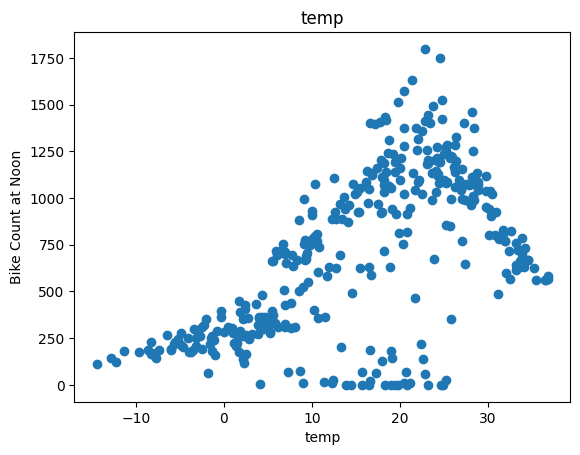

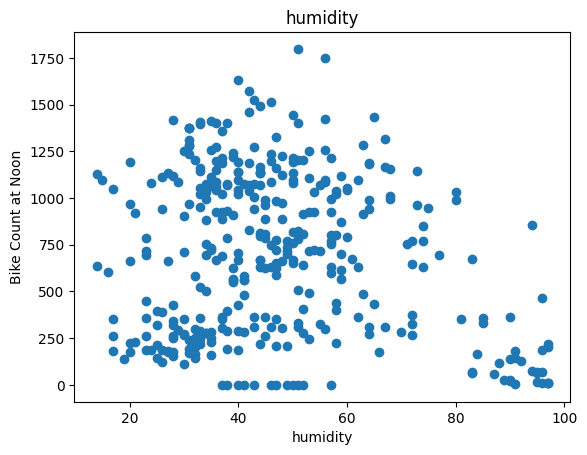

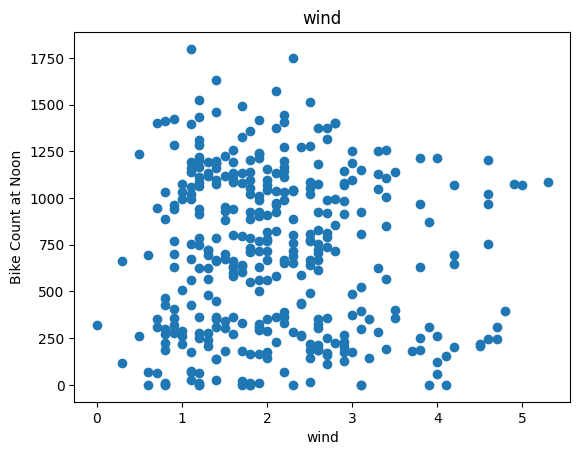

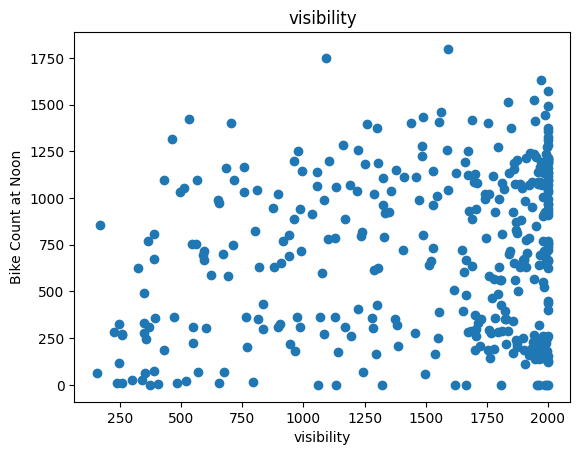

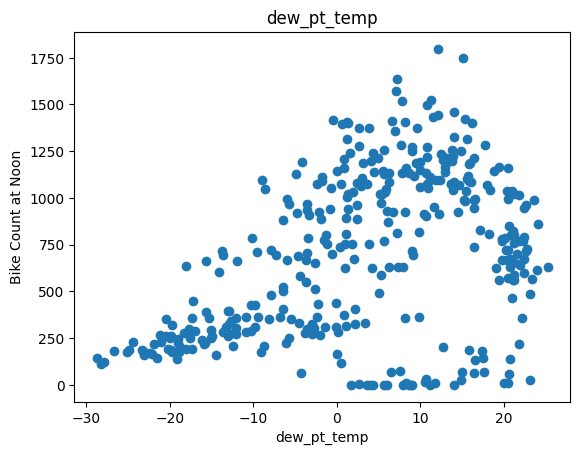

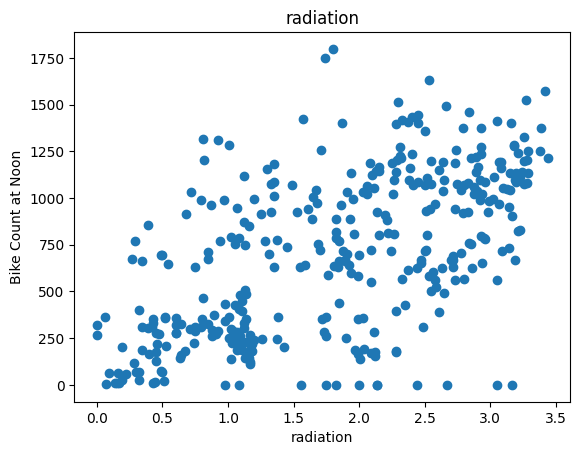

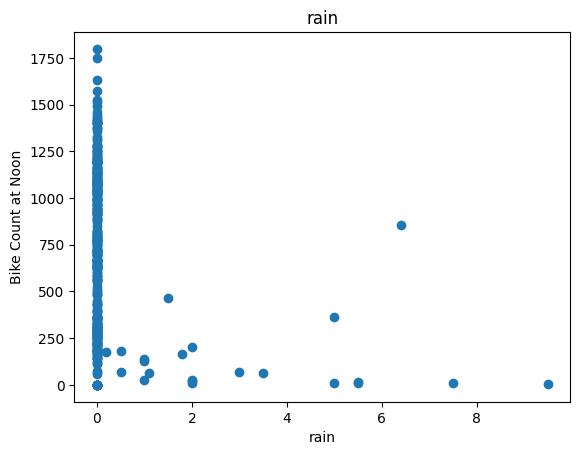

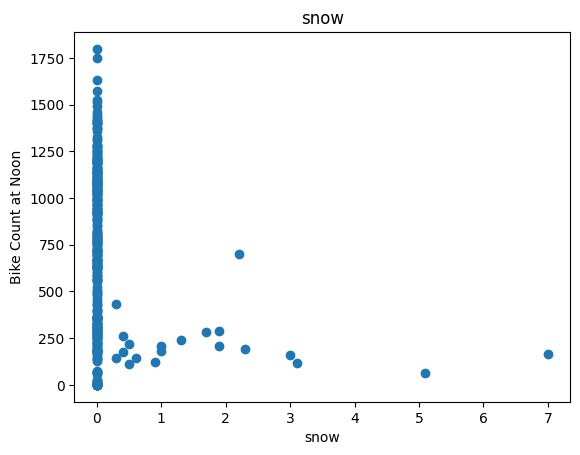

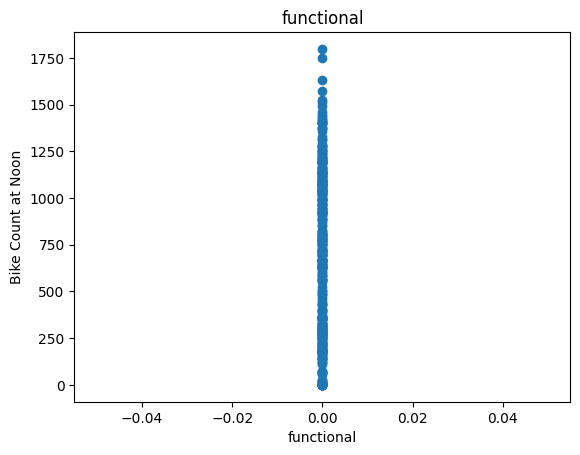

In [17]:
for label in df.columns[1:]:
    plt.scatter(df[label], df["bike_count"])
    plt.title(label)
    plt.ylabel("Bike Count at Noon")
    plt.xlabel(label)
    plt.show()

In [18]:
df = df.drop(["wind", "visibility", "functional"], axis=1)
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


#Train/valid/test dataset

In [35]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

In [ ]:
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[x_labels].values
    
    y = dataframe[y_label].values.reshape(-1, 1)
    data = np.hstack((X, y))

    return data, X, y

In [23]:
_, X_train_temp, y_train_temp = get_xy(train, "bike_count", x_labels=["temp"])
_, X_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temp"])
_, X_test_temp, y_test_temp = get_xy(test, "bike_count", x_labels=["temp"])

In [25]:
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)


LinearRegression()

In [26]:
print(temp_reg.coef_, temp_reg.intercept_)

[[20.85373673]] [391.90412441]


In [28]:
# R squared
temp_reg.score(X_test_temp, y_test_temp)

0.32293156921928234

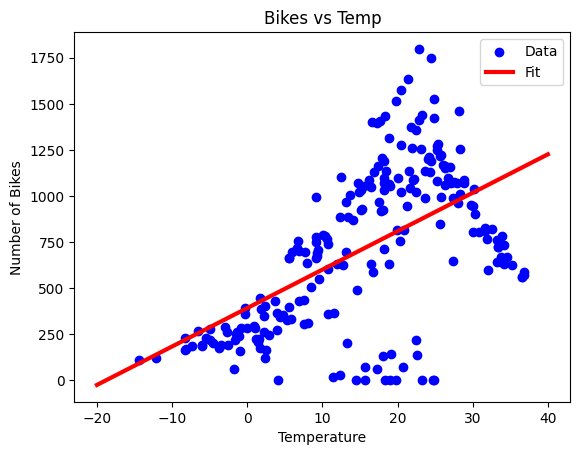

In [30]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label="Fit", color='red', linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of Bikes")
plt.xlabel("Temperature")
plt.show()

# Multiple Linear Regression


In [31]:
df.columns

Index(['bike_count', 'temp', 'humidity', 'dew_pt_temp', 'radiation', 'rain',
       'snow'],
      dtype='object')

In [37]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])
col_list = list(df.columns[1:])
_, X_train_all, y_train_all = get_xy(train, "bike_count", x_labels=col_list)
_, X_val_all, y_val_all = get_xy(val, "bike_count", x_labels=col_list)
_, X_test_all, y_test_all = get_xy(test, "bike_count", x_labels=col_list)

/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [38]:
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

LinearRegression()

In [39]:
all_reg.score(X_test_all, y_test_all)

0.5386799536545672

In [80]:
y_pred_lr = all_reg.predict(X_test_all)

# Regression with Neural Net

In [46]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

In [40]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)
])

In [44]:
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mean_squared_error')

In [47]:
history = temp_nn_model.fit(
    X_train_temp.reshape(-1), y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(X_val_temp, y_val_temp)
)

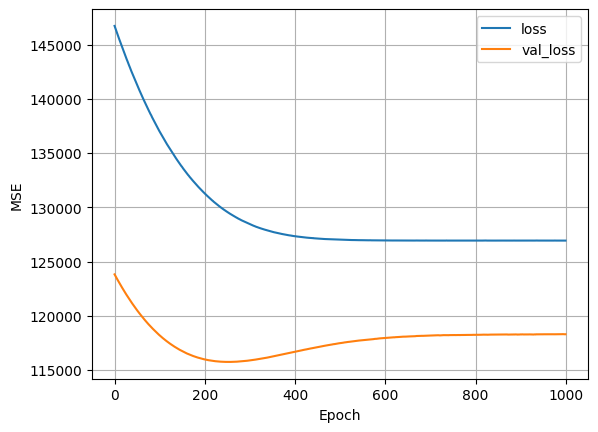

In [48]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


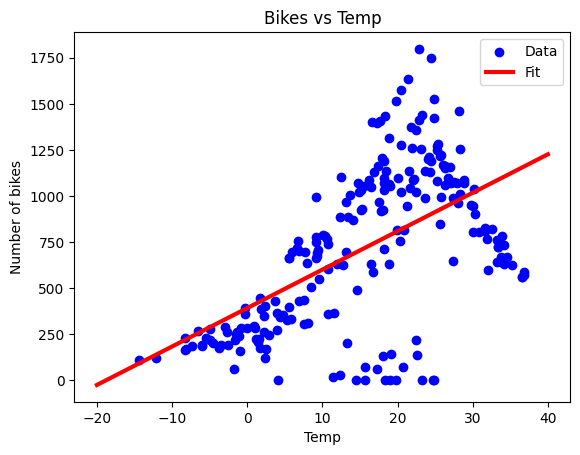

In [49]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

# Neural Net

In [64]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')


In [65]:
history = nn_model.fit(
    X_train_temp, y_train_temp,
    validation_data=(X_val_temp, y_val_temp),
    verbose=0,
    epochs=100
)

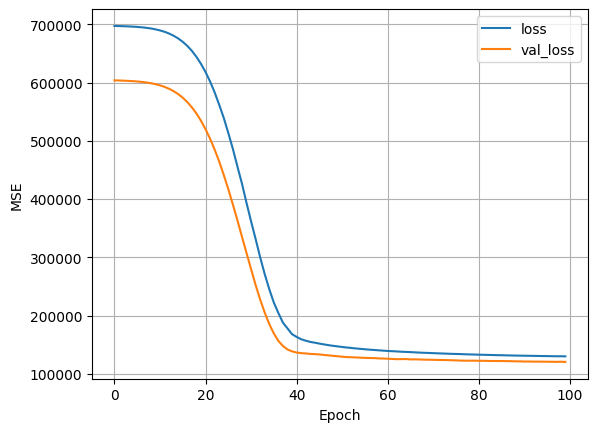

In [66]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


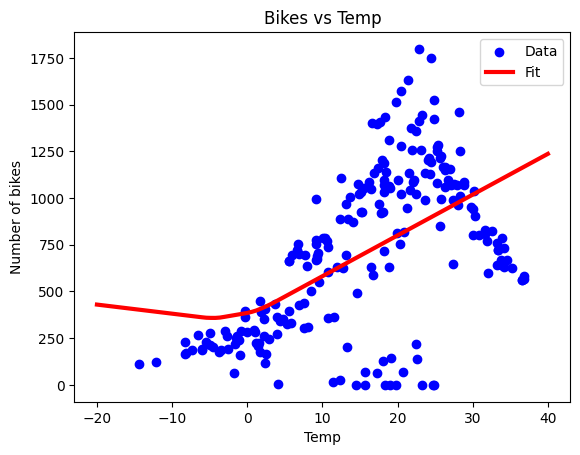

In [67]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

In [74]:
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,), axis=1)
all_normalizer.adapt(X_train_all)

In [75]:
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

In [76]:
history = nn_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val_all, y_val_all),
    verbose=0, epochs=100
)

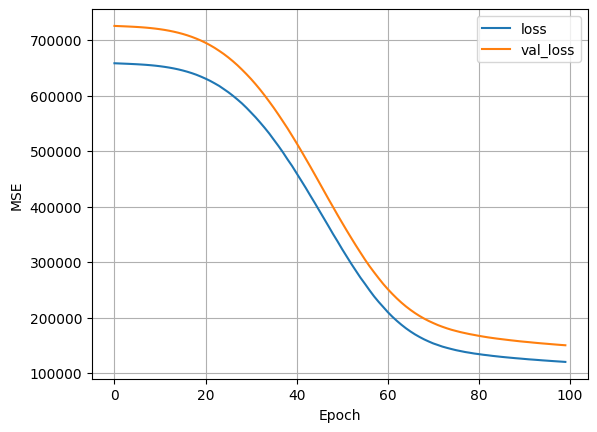

In [77]:
plot_loss(history)

In [81]:
# calculate the MSE for both linear reg and nn
y_pred_lr = all_reg.predict(X_test_all)
y_pred_nn = nn_model.predict(X_test_all)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [82]:
def MSE(y_pred, y_real):
    return (np.square(y_pred - y_real)).mean()


In [83]:
MSE(y_pred_lr, y_test_all)

np.float64(85717.75159552676)

In [84]:
MSE(y_pred_nn, y_test_all)

np.float64(116886.32065205408)

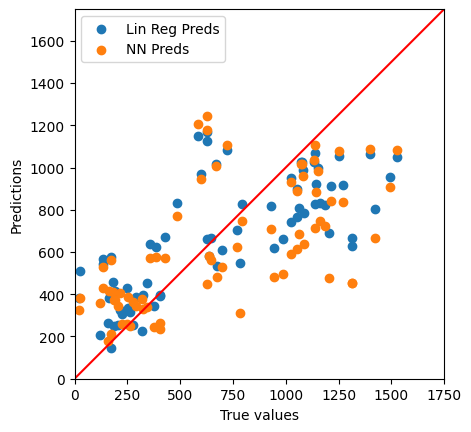

In [89]:
ax = plt.axes(aspect="equal")
plt.scatter(y_test_all, y_pred_lr, label="Lin Reg Preds")
plt.scatter(y_test_all, y_pred_nn, label="NN Preds")
plt.xlabel('True values')
plt.ylabel("Predictions")
lims = [0, 1750]
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
_ = plt.plot(lims, lims, c="red")

# Unsupervised Learning

# K-Means Clustering

K-means clustering is trying to compute $k$ clusters from the data.

In the graph below, it looks like $k=3$ could be a good choice. The $k$ that we choose is predefined by you.

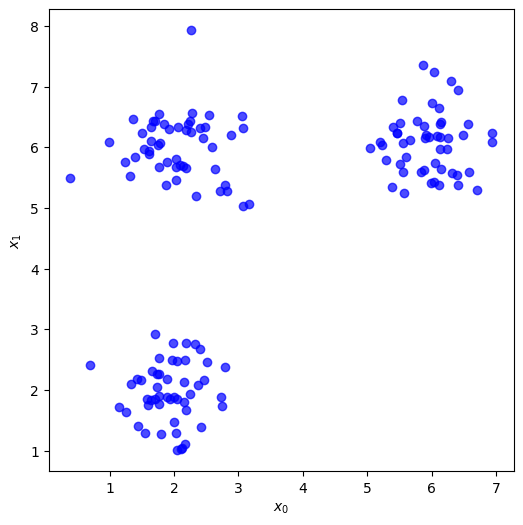

In [91]:
# Generic scatterplot with three clusters
np.random.seed(42)
cluster1 = np.random.normal(loc=(2, 2), scale=0.5, size=(50, 2))
cluster2 = np.random.normal(loc=(6, 6), scale=0.5, size=(50, 2))
cluster3 = np.random.normal(loc=(2, 6), scale=0.5, size=(50, 2))

data = np.vstack([cluster1, cluster2, cluster3])
labels = np.array([0]*50 + [1]*50 + [2]*50)

plt.figure(figsize=(6, 6))
for i, color in zip([0, 1, 2], ['blue', 'blue', 'blue']):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], color=color, label=f'Cluster {i+1}', alpha=0.7)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.show()

Steps for choosing the clusters (assuming $k=3$):
- Choose 3 random points on the above plot to be the centroids (center of the clusters)
- Calculate the distance between all the points and the centroid. All points get assigned to the closest centroid
- Compute new centroids based on all the points we have in the centroids. This is an iterative process. New centroids keep getting re-calculated, and new clusters around these new centroids. Steps 2 and three keep going until we converge on a stable solution. This process is called **Expectation Maximization**. Assigning points to the closest centroid is the **expectation step** and when we compute new centroids, that is known as the **maximization step**.

# Principal Component Analysis

This is often used as a **dimensionality reduction** technique. If I have a bunch of features, we sometimes want to reduce that down to one dimension that gives us the most information. 

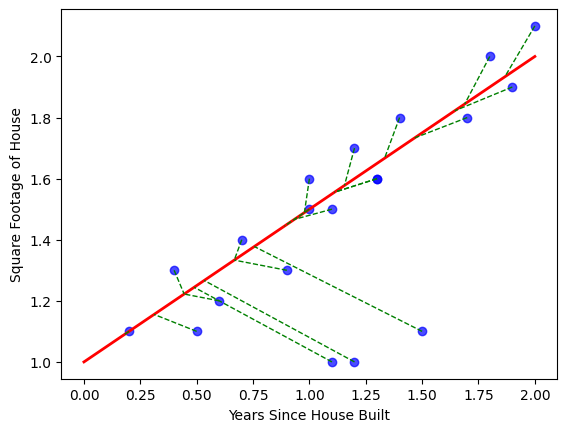

In [108]:
x = [1.1, 0.2, 1.3, 0.4, 0.5, 0.6, 0.7, 1, 0.9, 1.0,
     1.1, 1.2, 1.3, 1.4, 1.5, 1.2, 1.7, 1.8, 1.9, 2.0]
y = [1.0, 1.1, 1.6, 1.3, 1.1, 1.2, 1.4, 1.5, 1.3, 1.6,
     1.5, 1.7, 1.6, 1.8, 1.1, 1, 1.8, 2.0, 1.9, 2.1]

plt.scatter(x, y, color='blue', alpha=0.7)
plt.plot([0, 2], [1, 2], color='red', linewidth=2)

# Draw lines from each point to the line y = 0.5x + 1
for xi, yi in zip(x, y):
    # Closest point on the line
    x_proj = (xi + 2*yi - 2) / 2.25
    y_proj = 0.5 * x_proj + 1
    plt.plot([xi, x_proj], [yi, y_proj], color='green', linestyle='--', linewidth=1)

plt.xlabel("Years Since House Built")
plt.ylabel("Square Footage of House")
plt.show()

Principle Component is the component (direction in space) with the largest variance. This would map each point to the line, and then create a new one-dimensional dataset. 

The PCA Dimension:
- minimize the projection residuals
- or, maximize the variance between the points

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
cols = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "class"]
df = pd.read_csv('data/seeds_dataset.txt', names=cols, sep="\s+")

In [113]:
df.head()

,area,perimeter,compactness,length,width,asymmetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


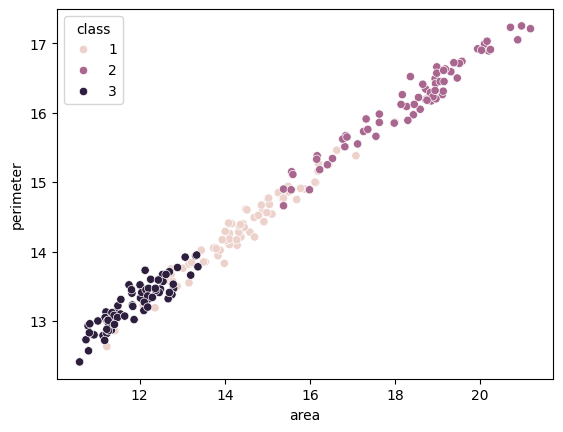

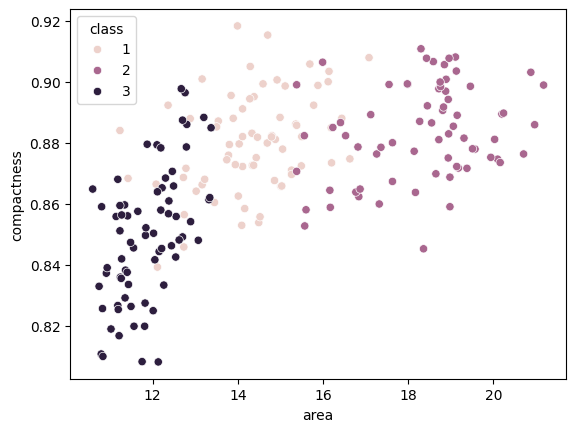

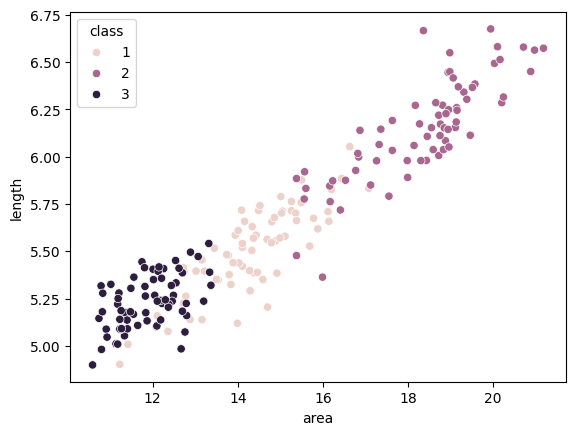

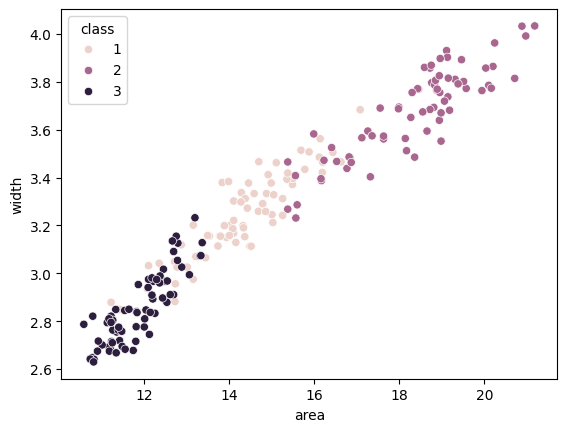

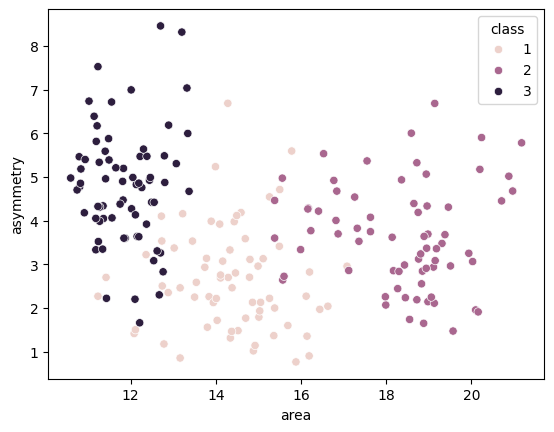

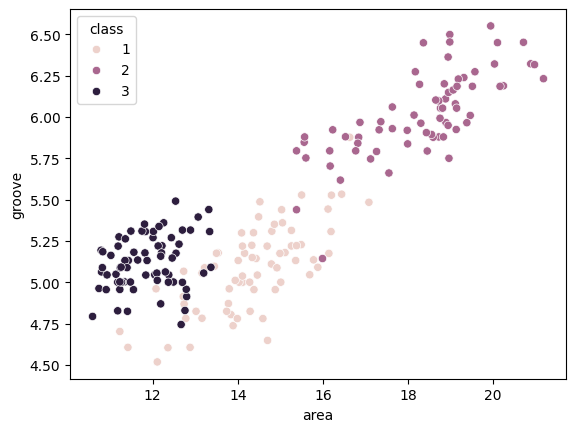

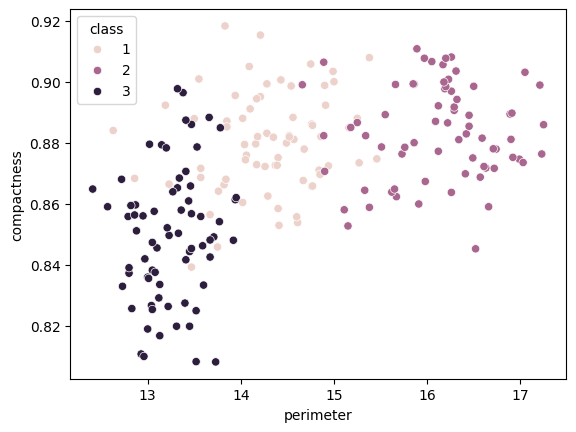

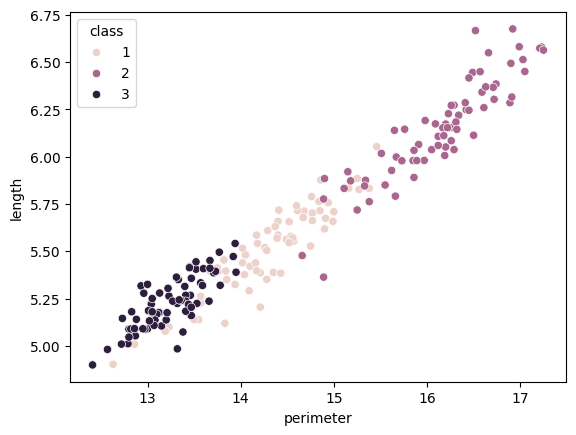

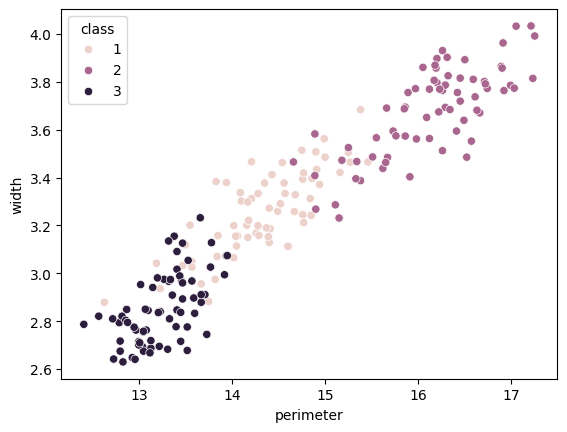

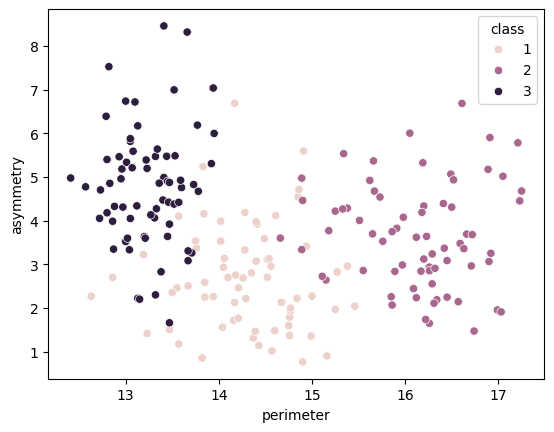

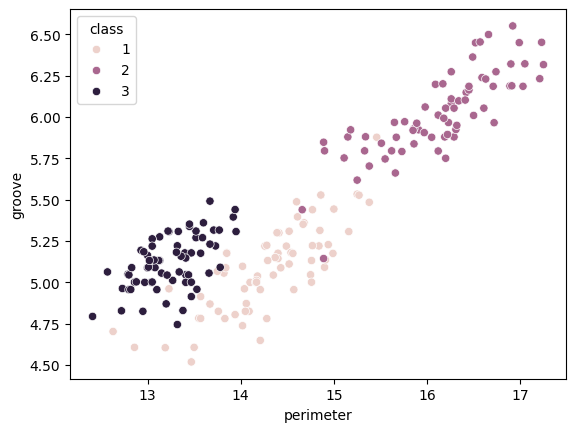

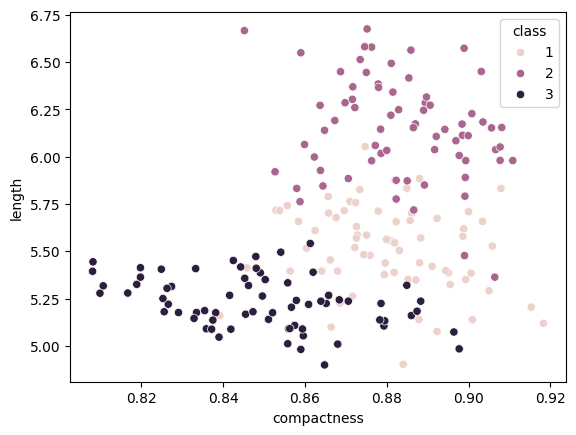

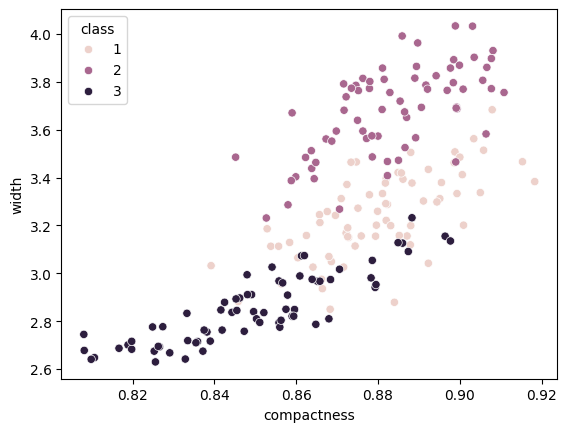

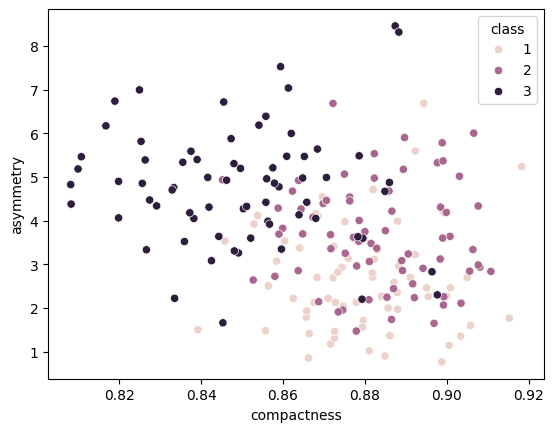

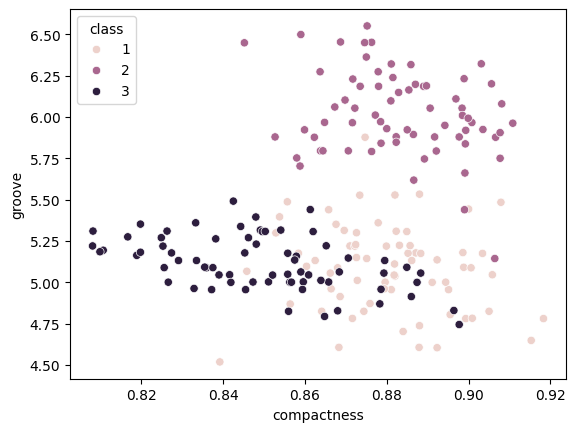

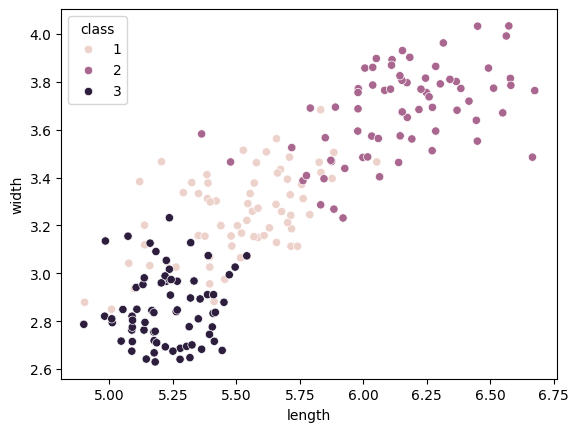

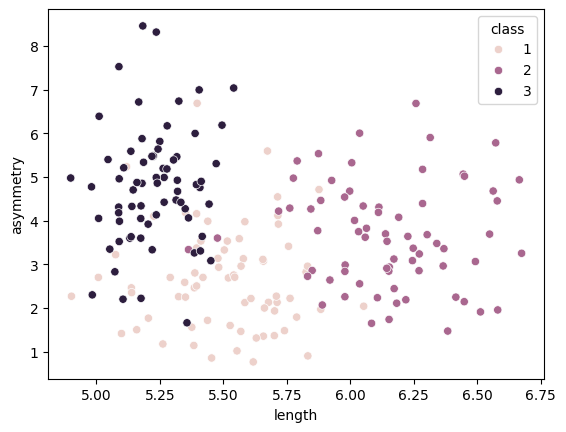

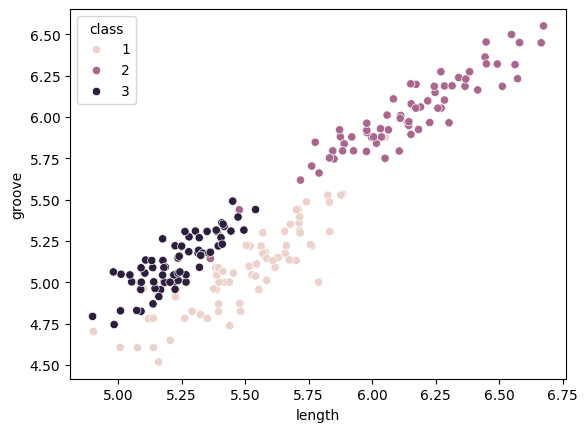

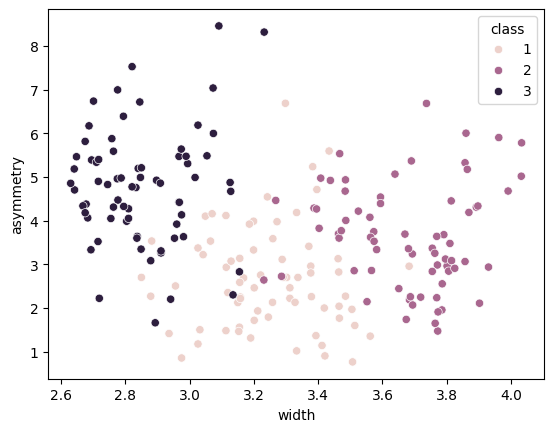

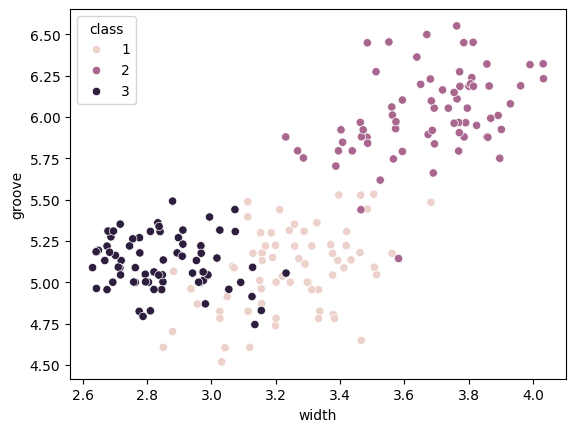

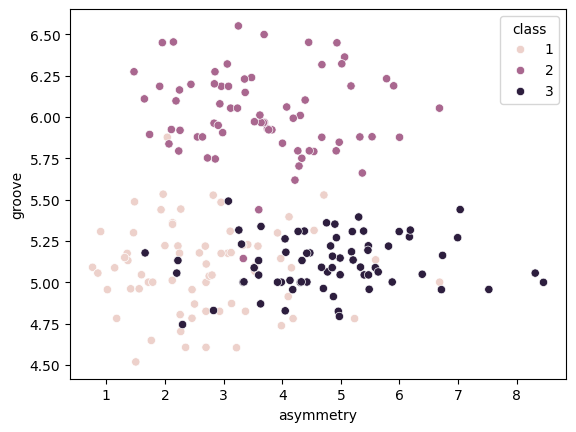

In [115]:
for i in range(len(cols)-1):
    for j in range(i+1, len(cols)-1):
        x_label = cols[i]
        y_label = cols[j]
        sns.scatterplot(x=x_label, y=y_label, data=df, hue='class')
        plt.show()

# Clustering

In [116]:
from sklearn.cluster import KMeans

In [133]:
x = "compactness"
y = "asymmetry"
X = df[[x, y]].values

In [134]:
kmeans = KMeans(n_clusters = 3).fit(X)

In [135]:
clusters = kmeans.labels_

In [136]:
clusters

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1,
       2, 2, 0, 1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 2, 0, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 2, 2, 2, 1, 2, 0, 1, 1, 2, 2, 2, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 0, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1,
       2, 1, 2, 0, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 1,
       1, 0, 2, 0, 1, 2, 1, 1, 1, 2, 1, 2], dtype=int32)

In [122]:
df['class'].values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [124]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1, 1))), columns=[x, y, "class"])

[]

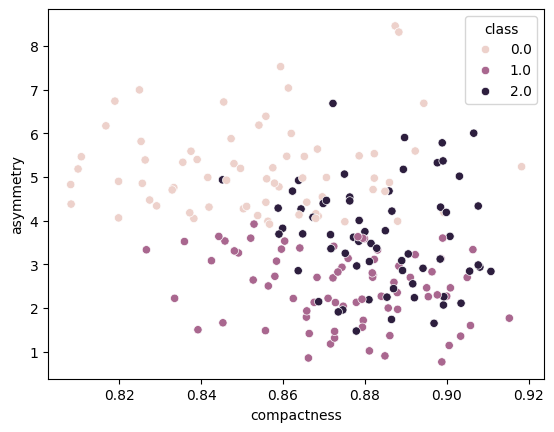

In [137]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

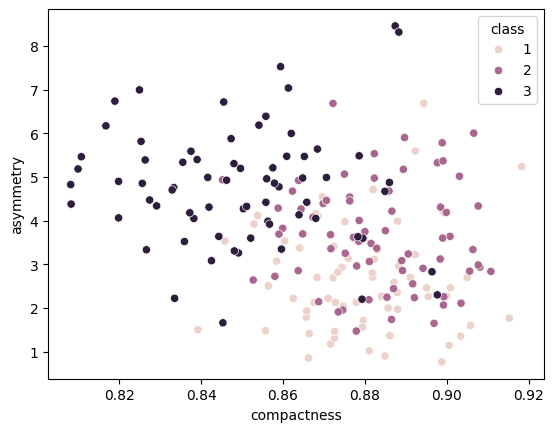

In [138]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

# Higher Dimensions

In [139]:
X = df[cols[:-1]].values

In [142]:
kmeans = KMeans(n_clusters = 3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1, 1))), columns=df.columns)

/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andy/freecodecamp/2026/machine_learning_for_everybody/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[]

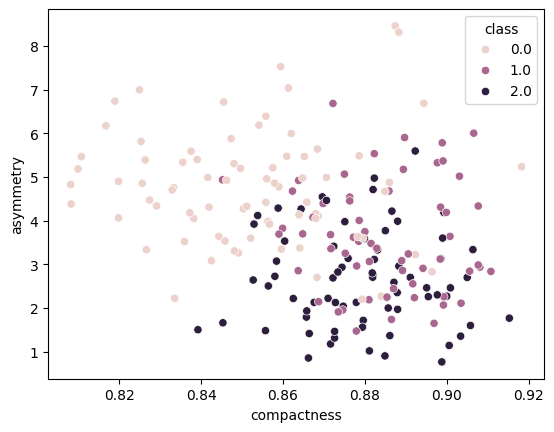

In [143]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

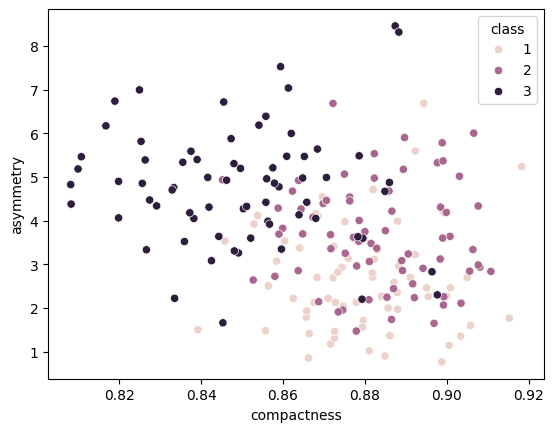

In [144]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

# PCA

In [145]:
from sklearn.decomposition import PCA

In [146]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)

In [147]:
X.shape

(210, 7)

In [148]:
transformed_x.shape

(210, 2)

In [149]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

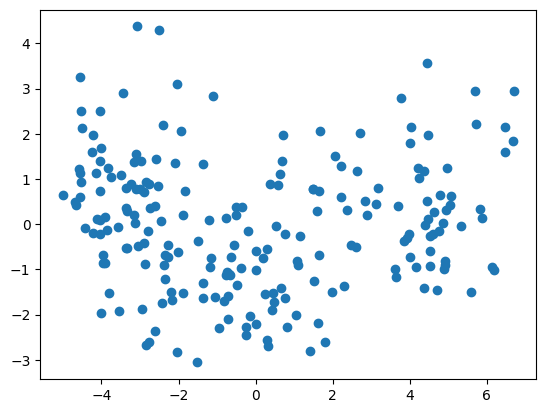

In [151]:
plt.scatter(transformed_x[:,0], transformed_x[:, 1]);

In [155]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1, 1))), columns=["pca1", "pca2", "class"])

In [156]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1, 1))), columns=["pca1", "pca2", "class"])

[]

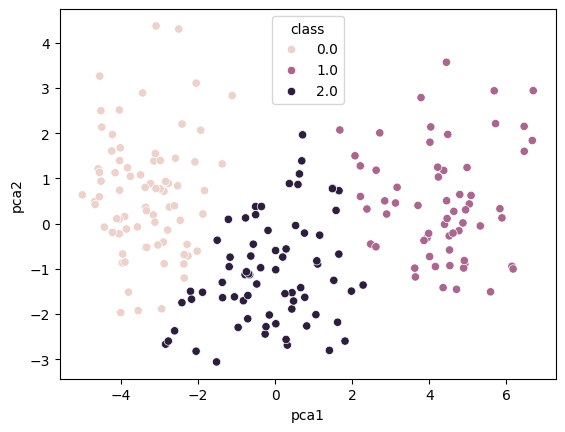

In [157]:
# K Means classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=kmeans_pca_df)
plt.plot()

[]

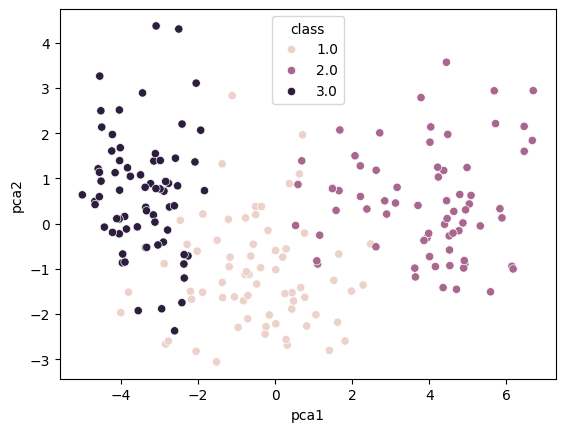

In [158]:
# Truth classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=truth_pca_df)
plt.plot()